In [1]:
%cd /home/anw2067/visualnav-transformer/train
import random

from torch.utils.data import DistributedSampler

from planning.utils import get_nymeria_dataset, load_policy
from torch.utils.data import DataLoader
import numpy as np
import os
import torch 

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

/scratch/anw2067/conda/envs/nomad_train2/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


/home/anw2067/visualnav-transformer/train


/scratch/anw2067/conda/envs/nomad_train2/lib/python3.10/site-packages/wandb/sdk/internal/internal_api.py:12: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version
/scratch/anw2067/conda/envs/nomad_train2/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
PEVA_FILES = {
    8: [
        "/home/anw2067/visualnav-transformer/train/logs/cem/2026_01_26_16_55_41:peva_cem-h8-n8-t2-v0.05-o6-N64-ds64-rank:ws-0:2",
        "/home/anw2067/visualnav-transformer/train/logs/cem/2026_01_26_16_55_45:peva_cem-h8-n8-t2-v0.05-o6-N64-ds64-rank:ws-1:2",
    ],
    16: [
        "/home/anw2067/visualnav-transformer/train/logs/cem/2026_01_25_02_03_32:peva_cem-h8-n16-t2-v0.05-o6-N64-ds64-rank:ws-0:2",
        "/home/anw2067/visualnav-transformer/train/logs/cem/2026_01_25_03_33_17:peva_cem-h8-n16-t2-v0.05-o6-N64-ds64-rank:ws-1:2",
    ],
    64: [
        "/home/anw2067/visualnav-transformer/train/logs/cem/2026_01_25_00_55_18:peva_cem-h8-n64-t2-v0.05-o6-N64-ds64-rank:ws-0:5",
        "/home/anw2067/visualnav-transformer/train/logs/cem/2026_01_25_00_56_38:peva_cem-h8-n64-t2-v0.05-o6-N64-ds64-rank:ws-2:5",
        "/home/anw2067/visualnav-transformer/train/logs/cem/2026_01_25_00_56_38:peva_cem-h8-n64-t2-v0.05-o6-N64-ds64-rank:ws-1:5",
        "/home/anw2067/visualnav-transformer/train/logs/cem/2026_01_25_00_56_34:peva_cem-h8-n64-t2-v0.05-o6-N64-ds64-rank:ws-3:5",
        "/home/anw2067/visualnav-transformer/train/logs/cem/2026_01_25_01_01_50:peva_cem-h8-n64-t2-v0.05-o6-N64-ds64-rank:ws-4:5"
    ]
}

WAYPOINT_FILES = {
    8: [
        "/home/anw2067/visualnav-transformer/train/logs/cem/2026_01_26_16_55_46:waypoint_cem-h1-n8-t4-v0.3-o6-N64-ds64-rank:ws-0:2",
        "/home/anw2067/visualnav-transformer/train/logs/cem/2026_01_26_16_55_46:waypoint_cem-h1-n8-t4-v0.3-o6-N64-ds64-rank:ws-1:2",
    ],
    16: [
        "/home/anw2067/visualnav-transformer/train/logs/cem/2026_01_25_02_02_20:waypoint_cem-h1-n16-t4-v0.3-o6-N64-ds64-rank:ws-0:2",
        "/home/anw2067/visualnav-transformer/train/logs/cem/2026_01_25_02_17_03:waypoint_cem-h1-n16-t4-v0.3-o6-N64-ds64-rank:ws-1:2",
    ],
    64: [
        "/home/anw2067/visualnav-transformer/train/logs/cem/2026_01_25_00_55_01:waypoint_cem-h1-n64-t4-v0.3-o6-N64-ds64-rank:ws-0:5",
        "/home/anw2067/visualnav-transformer/train/logs/cem/2026_01_25_00_55_36:waypoint_cem-h1-n64-t4-v0.3-o6-N64-ds64-rank:ws-1:5",
        "/home/anw2067/visualnav-transformer/train/logs/cem/2026_01_25_00_56_38:waypoint_cem-h1-n64-t4-v0.3-o6-N64-ds64-rank:ws-2:5",
        "/home/anw2067/visualnav-transformer/train/logs/cem/2026_01_25_00_56_39:waypoint_cem-h1-n64-t4-v0.3-o6-N64-ds64-rank:ws-3:5",
        "/home/anw2067/visualnav-transformer/train/logs/cem/2026_01_25_00_56_35:waypoint_cem-h1-n64-t4-v0.3-o6-N64-ds64-rank:ws-4:5"
    ]
}

filename = "accum_objective_metric_dicts.pth"


In [3]:
all_peva_keys = set()
all_waypoint_keys = set()

def extract_metric_data(data_dict):
    num_tracks = len(data_dict.keys())
    res_matrix = np.zeros((num_tracks, 6))
    for t_idx, track in enumerate(data_dict.keys()):
        for entry_idx, entry in enumerate(data_dict[track]):
            res_matrix[t_idx, entry_idx] = entry['loss']
    return res_matrix.mean(axis=0)

PEVA_CEM = {}
for n in PEVA_FILES.keys():
    PEVA_CEM[n] = []
    for folder in PEVA_FILES[n]:
        file = os.path.join(folder, filename)
        data = torch.load(file)
        keys = list(data.keys())
        all_peva_keys.update(keys)
        PEVA_CEM[n]= list(extract_metric_data(data))
        
WAYPOINT_CEM = {}
for n in WAYPOINT_FILES.keys():
    WAYPOINT_CEM[n] = []
    for folder in WAYPOINT_FILES[n]:
        file = os.path.join(folder, filename)
        data = torch.load(file)
        keys = list(data.keys())
        all_waypoint_keys.update(keys)
        WAYPOINT_CEM[n] = list(extract_metric_data(data))

In [4]:
len(all_peva_keys)

214

In [5]:
device = "cuda"
from dreamsim import dreamsim
dreamsim_model, dreamsim_preprocess = dreamsim(pretrained=True, device=device, cache_dir="/scratch/anw2067/cache")

Using cached /scratch/anw2067/cache


Using cache found in /scratch/anw2067/cache/facebookresearch_dino_main
/scratch/anw2067/conda/envs/nomad_train2/lib/python3.10/site-packages/torch/nn/utils/weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)
/scratch/anw2067/conda/envs/nomad_train2/lib/python3.10/site-packages/peft/tuners/tuners_utils.py:282: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn(


In [6]:
# from torchvision import transforms

# seed = 42
# random.seed(seed)
# np.random.seed(seed)
# torch.manual_seed(seed)
# if torch.cuda.is_available():
#     torch.cuda.manual_seed(seed)
#     torch.cuda.manual_seed_all(seed)


    
# # reconstruction of the dreamSIM metrics for the first 200 examples
# NOMAD_CKPT = "/home/anw2067/visualnav-transformer/train/logs/nomad-minimal/2026_01_21_06_54:nomad-minimal-proprioception-cat8-dinov3_unpool_3dposemb-proj-lr5e-4-pool_curr_obs-goaldraw-waypointMask/ema_9.pth"
# NOMAD_CFG = "/home/anw2067/visualnav-transformer/train/config/torch/minimal-nomad-proprioception-cat8-dinov3_unpool_3dposemb-proj-lr5e-4-pool_curr_obs-goaldraw-waypointMask.yaml"

# policy, policy_diffusion, nomad_stats, nomad_config = load_policy(NOMAD_CFG, NOMAD_CKPT, device=device)
# dataset = get_nymeria_dataset(nomad_config, context_size=6, goal_timestep_offset=8)
# sampler = DistributedSampler(dataset, num_replicas=1, rank=0, shuffle=True, seed=seed)
# dataloader = DataLoader(dataset, batch_size=1, sampler=sampler)

# count = 0
# res = []
# for idx, batch in enumerate(dataloader):
#     ex_str = f"{batch['dataset_track'][0]}-{batch['dataset_track_index'].item()}"
#     if ex_str in all_peva_keys:
#         count += 1
        
#         current_img = batch['obs_images'][0, -1]
#         goal_obs = batch['goal_obs'][0]
        
#         current_pil = transforms.ToPILImage()(current_img)
#         goal_pil = transforms.ToPILImage()(goal_obs)
        
#         current_tensor = dreamsim_preprocess(current_pil).to(device)
#         goal_tensor = dreamsim_preprocess(goal_pil).to(device)
        
#         sim = dreamsim_model(current_tensor, goal_tensor).item()
#         res.append(sim)
        
#         if count == len(all_peva_keys):
#             break

# print(f"np.mean(res): {np.mean(res)}")
# average_sim = np.mean(res)
average_sim = 0.25815232251292075

In [7]:
# add the average sim to the start of the graphing data
for n in PEVA_CEM.keys():
    PEVA_CEM[n] = [average_sim] + PEVA_CEM[n]
    
for n in WAYPOINT_CEM.keys():
    WAYPOINT_CEM[n] = [average_sim] + WAYPOINT_CEM[n]


In [8]:
from pprint import pprint 
pprint(PEVA_CEM)

{8: [0.25815232251292075,
     0.3564599745049335,
     0.3410459538497547,
     0.32730040913171105,
     0.32082058319655976,
     0.31049031587225373,
     0.30650344586903505],
 16: [0.25815232251292075,
      0.35597539021827207,
      0.3355830091946196,
      0.31838632692204843,
      0.30890339915410125,
      0.30177444758096544,
      0.2933613923516604],
 64: [0.25815232251292075,
      0.32443888848874625,
      0.30520131529831307,
      0.29182995383332416,
      0.2835095150441658,
      0.27411945382269415,
      0.27123753853687427]}


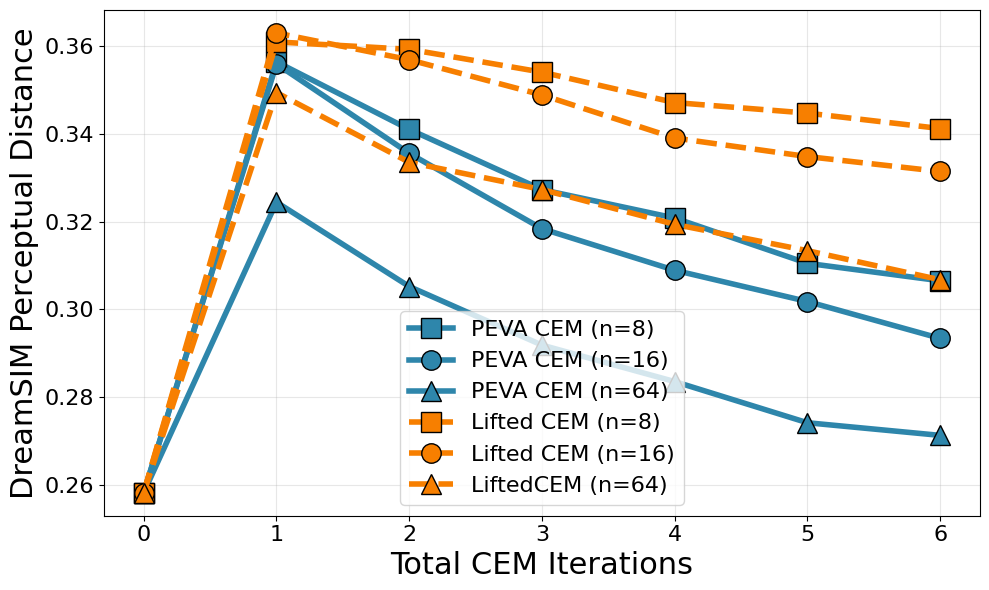

In [12]:
import matplotlib.pyplot as plt
import numpy as np
import os

# Prepare data
iterations = np.arange(0, 7)  # 0 to 6 (t=0 is starting distance, then iterations 1-6)

# Create the plot
plt.figure(figsize=(10, 6))

# Define colors for methods
peva_color = "#2E86AB"  # Deep teal/blue
waypoint_color = "#F77F00"  # Warm coral/orange

# Plot PEVA-CEM lines (solid, different markers for sample counts)
if PEVA_CEM[8]:
    plt.plot(iterations, PEVA_CEM[8], marker='s', markersize=14, label='PEVA CEM (n=8)', linewidth=4, color=peva_color, mec='k')
if PEVA_CEM[16]:
    plt.plot(iterations, PEVA_CEM[16], marker='o', markersize=14, label='PEVA CEM (n=16)', linewidth=4, color=peva_color, mec='k')
if PEVA_CEM[64]:
    plt.plot(iterations, PEVA_CEM[64], marker='^', markersize=14, label='PEVA CEM (n=64)', linewidth=4, color=peva_color, mec='k')

# Plot Waypoint-CEM lines (dashed, different markers for sample counts)
if WAYPOINT_CEM[8]:
    plt.plot(iterations, WAYPOINT_CEM[8], marker='s', markersize=14, linestyle='--', label='Lifted CEM (n=8)', linewidth=4, color=waypoint_color, mec='k')
if WAYPOINT_CEM[16]:
    plt.plot(iterations, WAYPOINT_CEM[16], marker='o', markersize=14, linestyle='--', label='Lifted CEM (n=16)', linewidth=4, color=waypoint_color, mec='k')
if WAYPOINT_CEM[64]:
    plt.plot(iterations, WAYPOINT_CEM[64], marker='^', markersize=14, linestyle='--', label='LiftedCEM (n=64)', linewidth=4, color=waypoint_color, mec='k')

# Customize the plot
plt.xlabel('Total CEM Iterations', fontsize=22)
plt.ylabel('DreamSIM Perceptual Distance', fontsize=22)
# plt.title('CEM Performance Comparison', fontsize=14)
plt.legend(fontsize=16, loc='best')
plt.grid(True, alpha=0.3)
plt.xticks(iterations, fontsize=16)
plt.yticks(fontsize=16)

plt.tight_layout()

plt.savefig(os.path.join("/home/anw2067/visualnav-transformer/train/logs/paper_vis/Planning-sweep", "cem_cost_convergence_v5.pdf"))

plt.show()


In [10]:
# import matplotlib.pyplot as plt
# import numpy as np
# import os

# # Prepare data
# iterations = np.arange(0, 7)  # 0 to 6 (t=0 is starting distance, then iterations 1-6)

# # Create the plot
# plt.figure(figsize=(10, 6))

# # Define colors for methods
# peva_color = "#2E86AB"  # Deep teal/blue
# waypoint_color = "#F77F00"  # Warm coral/orange

# # Plot PEVA-CEM lines (solid, different markers for sample counts)
# if PEVA_CEM[8]:
#     plt.plot(iterations, PEVA_CEM[8], marker='s', markersize=14, label='PEVA CEM (n=8)', linewidth=4, color=peva_color)
# if PEVA_CEM[16]:
#     plt.plot(iterations, PEVA_CEM[16], marker='o', markersize=14, label='PEVA CEM (n=16)', linewidth=4, color=peva_color)
# if PEVA_CEM[64]:
#     plt.plot(iterations, PEVA_CEM[64], marker='^', markersize=14, label='PEVA CEM (n=64)', linewidth=4, color=peva_color)

# # Plot Waypoint-CEM lines (dashed, different markers for sample counts)
# if WAYPOINT_CEM[8]:
#     plt.plot(iterations, WAYPOINT_CEM[8], marker='s', markersize=14, linestyle='--', label='Lifted CEM (n=8)', linewidth=4, color=waypoint_color)
# if WAYPOINT_CEM[16]:
#     plt.plot(iterations, WAYPOINT_CEM[16], marker='o', markersize=14, linestyle='--', label='Lifted CEM (n=16)', linewidth=4, color=waypoint_color)
# if WAYPOINT_CEM[64]:
#     plt.plot(iterations, WAYPOINT_CEM[64], marker='^', markersize=14, linestyle='--', label='LiftedCEM (n=64)', linewidth=4, color=waypoint_color)

# # Customize the plot
# plt.xlabel('CEM Iterations', fontsize=22)
# plt.ylabel('DreamSIM Perceptual Distance', fontsize=22)
# # plt.title('CEM Performance Comparison', fontsize=14)
# plt.legend(fontsize=16, loc='best')
# plt.grid(True, alpha=0.3)
# plt.xticks(iterations, fontsize=16)
# plt.yticks(fontsize=16)

# plt.tight_layout()

# plt.savefig(os.path.join("/home/anw2067/visualnav-transformer/train/logs/paper_vis/Planning-sweep", "cem_cost_convergence_v4.pdf"))

# plt.show()


In [11]:
# import matplotlib.pyplot as plt
# import numpy as np
# import os

# # Prepare data
# iterations = np.arange(0, 7)  # 0 to 6 (t=0 is starting distance, then iterations 1-6)

# # Create the plot
# plt.figure(figsize=(10, 6))

# # Plot PEVA-CEM lines
# if PEVA_CEM[16]:
#     plt.plot(iterations, PEVA_CEM[16], marker='o', label='PEVA-CEM (n=16)', linewidth=2)
# if PEVA_CEM[32]:
#     plt.plot(iterations, PEVA_CEM[32], marker='s', label='PEVA-CEM (n=32)', linewidth=2)
# if PEVA_CEM[64]:
#     plt.plot(iterations, PEVA_CEM[64], marker='^', label='PEVA-CEM (n=64)', linewidth=2)

# # Plot Waypoint-CEM lines
# if WAYPOINT_CEM[16]:
#     plt.plot(iterations, WAYPOINT_CEM[16], marker='o', linestyle='--', label='Waypoint-CEM (n=16)', linewidth=2)
# if WAYPOINT_CEM[32]:
#     plt.plot(iterations, WAYPOINT_CEM[32], marker='s', linestyle='--', label='Waypoint-CEM (n=32)', linewidth=2)
# if WAYPOINT_CEM[64]:
#     plt.plot(iterations, WAYPOINT_CEM[64], marker='^', linestyle='--', label='Waypoint-CEM (n=64)', linewidth=2)

# # Customize the plot
# plt.xlabel('CEM Iterations', fontsize=12)
# plt.ylabel('Mean Joint Error (m)', fontsize=12)
# # plt.title('CEM Performance Comparison', fontsize=14)
# plt.legend(fontsize=10, loc='best')
# plt.grid(True, alpha=0.3)
# plt.xticks(iterations)
# plt.tight_layout()

# plt.savefig(os.path.join("/home/anw2067/visualnav-transformer/train/logs/paper_vis/Planning-sweep", "cem_metric_performance.pdf"))

# plt.show()
